# Modelo con K Means

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm
import plotly.express as px

import seaborn as sns

import pandas as pd

In [3]:
df_dqi =pd.read_csv('./Data/Processed/df_dqi_final.csv', sep=';')
df_clustering_pca = pd.read_csv('./Data/Processed/df_clustering_pca.csv', sep=';')
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False


## Entrenamiento del modelo

Se crean funciones para el entrenamiento y la evaluación del modelo.

In [4]:


def kmeans(X, clusters,sample_weight=None):
    silhouette_scores = []

    for cluster in clusters:
        # a
        kmeans = KMeans(n_clusters=cluster, random_state=42)
        labels = kmeans.fit_predict(X,sample_weight=sample_weight)  # Ajustar el modelo y predecir los clusters
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_spider_plotly(centroids, k):
    # Crear un DataFrame con los centroides
    num_features = centroids.shape[1]
    feature_labels = [f'Feature {i + 1}' for i in range(num_features)]
    
    # Preparar los datos para Plotly
    data = []
    for i in range(k):
        values = centroids[i].tolist() + [centroids[i][0]]  # Cerrar el círculo
        data.append(values)
    
    # Crear un DataFrame
    df = pd.DataFrame(data, columns=feature_labels + ['Feature 1'])
    df['Cluster'] = [f'Cluster {i + 1}' for i in range(k)]
    df = pd.melt(df, id_vars='Cluster', value_vars=feature_labels, var_name='Feature', value_name='Value')

    # Gráfico de araña (radar)
    fig = px.line_polar(df, r='Value', theta='Feature', color='Cluster', line_close=True,
                         title=f'Spider Plot for {k} Clusters')
    
    fig.update_traces(fill='toself', opacity=0.25)  # Rellenar el área
    fig.show()



A continuación se realizará el proceso de clustering utilizando el método de KMeans. Para ello, se utilizará la función kmeans que recibe como parámetros los datosdespués de pasar por PCA y el rango de clusters a evaluar. En este caso, se evaluarán desde 2 hasta 10 clusters.

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


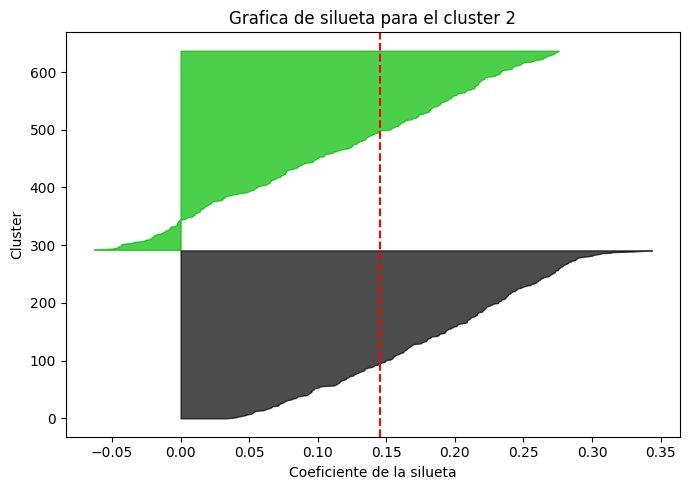

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


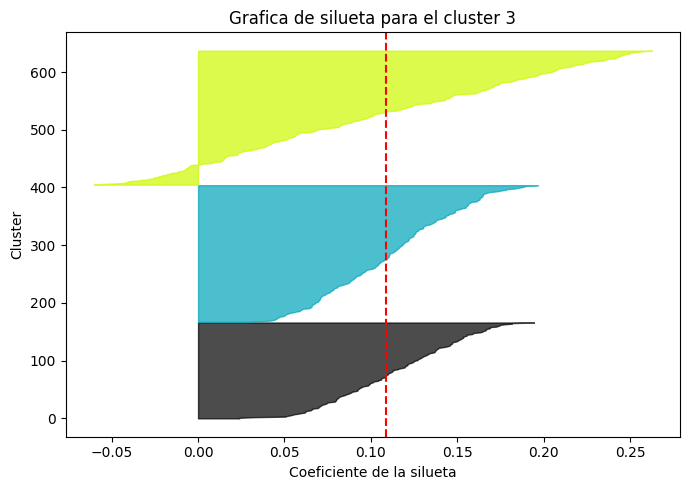

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


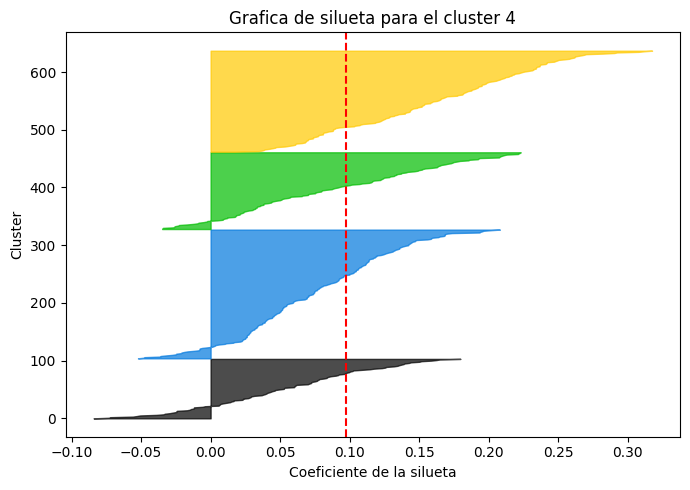

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


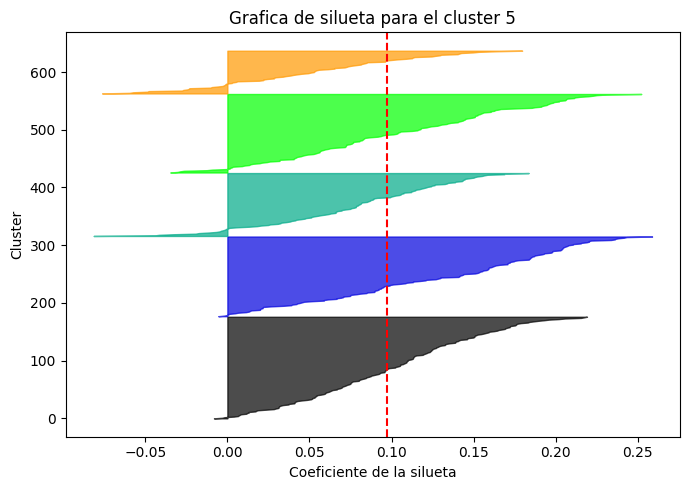

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


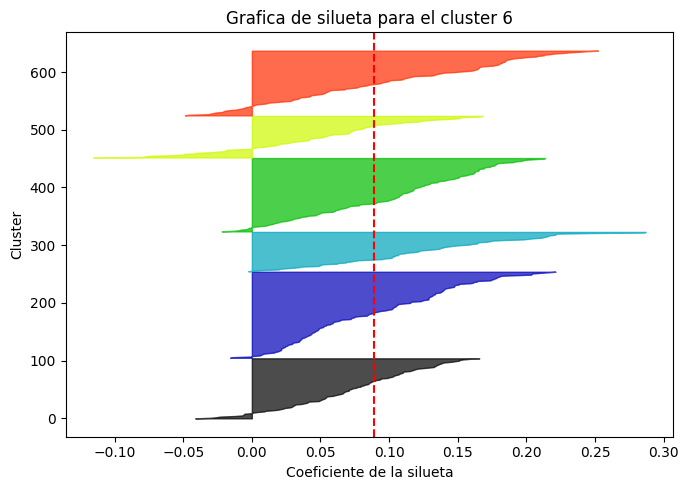

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


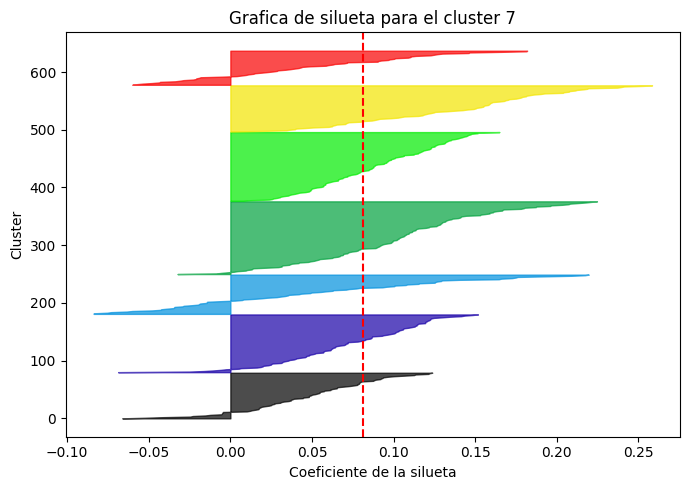

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


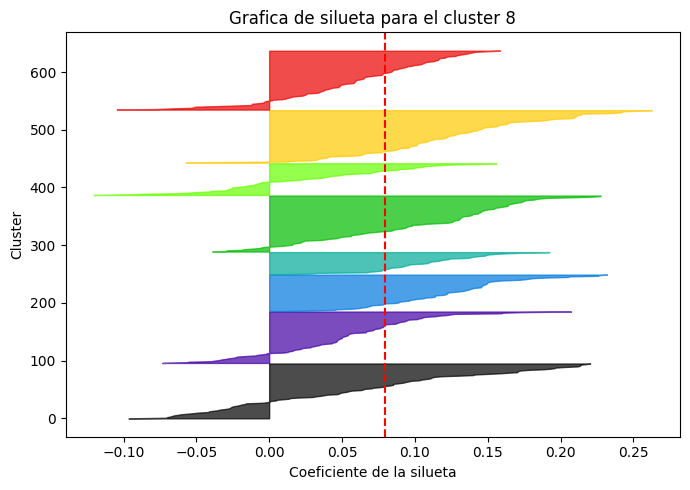

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


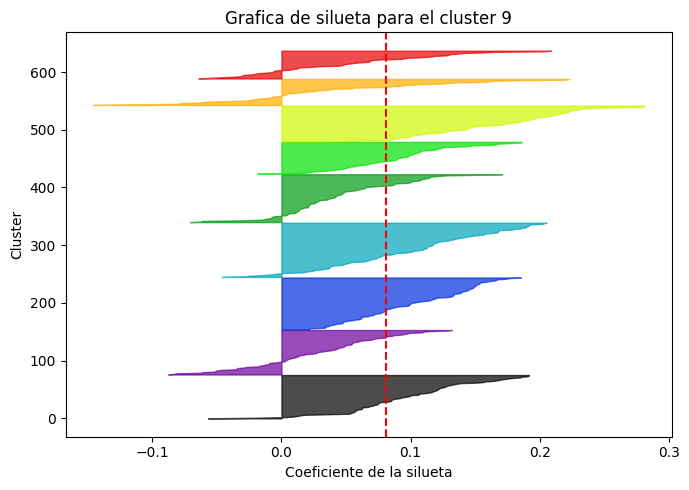

cluster = 2, Puntaje de Silueta = 0.14514684408245523
cluster = 3, Puntaje de Silueta = 0.10848190469135369
cluster = 4, Puntaje de Silueta = 0.09723917628370946
cluster = 5, Puntaje de Silueta = 0.09726701120360055
cluster = 6, Puntaje de Silueta = 0.0891125652627602
cluster = 7, Puntaje de Silueta = 0.08147055306635848
cluster = 8, Puntaje de Silueta = 0.07982488993665425
cluster = 9, Puntaje de Silueta = 0.08087763871955597


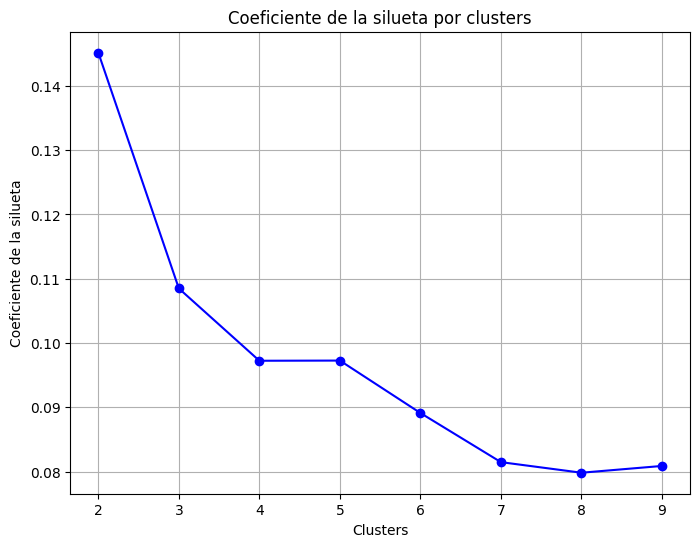

In [5]:

# Especificamos los números de clusters a evaluar
clusters = range(2, 10)  
# Ejecutamos KMeans y graficamos los resultados
silhouette_scores = kmeans(df_clustering_pca, clusters,sample_weight=df_dqi['ponderador'])
for cluster, score in zip(clusters, silhouette_scores):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')
# Graficamos el coeficiente de silueta para cada número de clusters
plot_silhouette_vs_cluster(clusters, silhouette_scores)


## Interpretación del modelo

Con base en el gráfico de la silueta podemos concluir que el número de cluster óptimo para nuestro modelo de K-Means es 2, dado que con este número se obtiene el coeficiente mayor. A continuación realizaremos el análisis la segmentación realizada con este número de clusters

In [6]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, max_iter=10000)
labels = kmeans.fit_predict(df_clustering_pca,sample_weight=df_dqi['ponderador'])
# Obtener los centroides
centroids = kmeans.cluster_centers_

# Graficar los centroides en un gráfico radial
plot_centroid_spider_plotly(centroids, n_clusters)

c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_core.py:271: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trace_data = trace_data.append(trace_data.iloc[0])
c:\Users\chris\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\express\_core.py:271: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trace_data = trace_data.append(trace_data.iloc[0])


Al analizar la gráfica araña podemos ver que los dos clusters tienen un comportamiento muy diferente en el primer componente principal, lo cual es bueno porque este es el componente que mayor variabilidad representa de todo el data set. A continuación realizaremos un análisis descriptivo comparando ambos clusters para identificar que representa esta diferencia.

In [7]:
df_dqi = df_dqi.assign(Cluster=labels)
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)",Cluster
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,True,False,False,False,False,False,True,False,False,0
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,0
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,0
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,True,False,False,False,False,False,True,False,False,1
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,True,False,False,False,False,False,True,False,False,0


In [8]:
## reversar one hot encoding

df_dqi['region'] = df_dqi[['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península']].idxmax(axis=1)
df_dqi['estrato'] = df_dqi[['estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)']].idxmax(axis=1)
df_dqi.drop(columns=['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península', 'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'], inplace=True)



In [9]:
# Crear una columna sexo a partir de la columna sexo_Mujer
df_dqi['sexo'] = df_dqi['sexo_Mujer'].map({True: 'Mujer', False: 'Hombre'})
df_dqi.drop(columns=['sexo_Mujer'], inplace=True)

In [10]:
df_dqi['region'] = df_dqi['region'].apply(lambda x: x.split('_')[1])
df_dqi['estrato'] = df_dqi['estrato'].apply(lambda x: x.split('_')[1])
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,31,60,51,8717.185479,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,32,58,26,51475.173556,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,31,60,62,7032.174356,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,20,40,33,27374.852298,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,37,63,60,15823.033532,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer


In [11]:
# normalizar ponderacion
df_dqi['ponderador'] = df_dqi['ponderador'].div(df_dqi['ponderador'].sum())

In [12]:
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,31,60,51,0.000122,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,32,58,26,0.000723,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,31,60,62,0.000099,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,20,40,33,0.000385,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,37,63,60,0.000222,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer


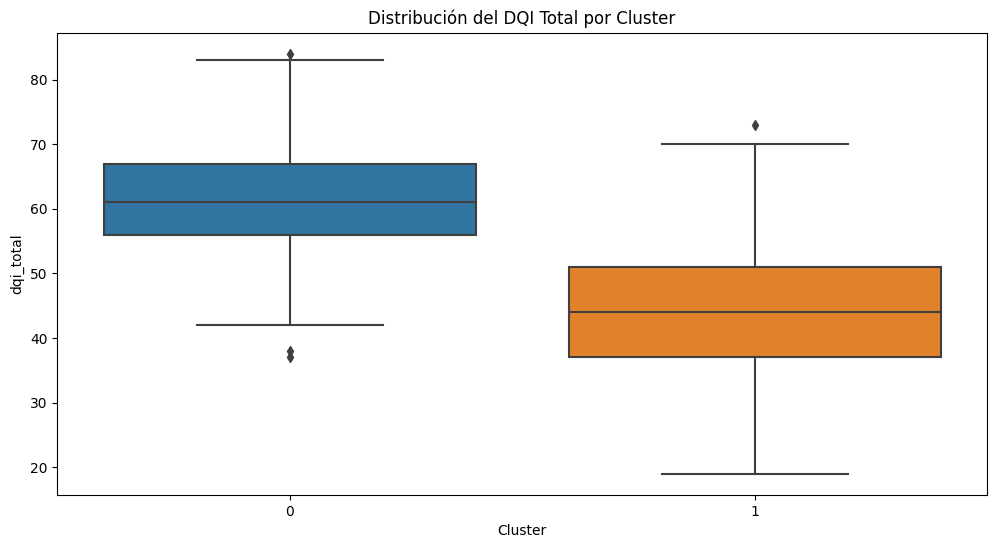

In [ ]:
# generar boxplot para dos columnas
def boxplot(df, x, y, hue=None, title=None):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=x, y=y, hue=hue, data=df)
    plt.title(title)
    plt.show()

boxplot(df_dqi, 'Cluster', 'dqi_total', title='Distribución del DQI Total por Cluster')

Al analizar la gráfica anterior podemos observar que el cluster 0 tiene un valor del dqi significativamente mayor que el cluster 1, ahora analicemos si este comportamiento se presenta en todos los grupos de edad o solo a nivel general.

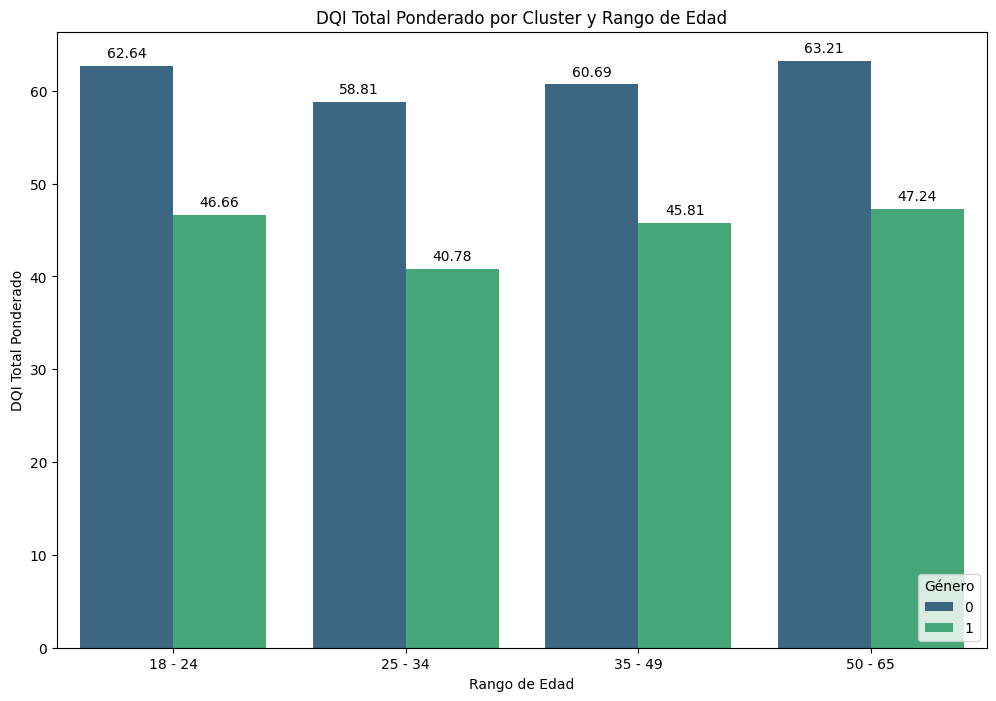

In [15]:
# Crear rangos de edad
labels = ['18 - 24', '25 - 34', '35 - 49', '50 - 65']
bins = [18, 25, 35, 50, 65]
df_dqi['edad_rango'] = pd.cut(df_dqi['edad'], bins=bins, labels=labels, right=False)

# Calcular el DQI total ponderado por género y rango de edad
weighted_dqi_by_gender_age = df_dqi.groupby(['Cluster', 'edad_rango']).apply(
    lambda x: (x['dqi_total'] * x['ponderador']).sum() / x['ponderador'].sum()
).reset_index(name='weighted_dqi_total')

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=weighted_dqi_by_gender_age, x='edad_rango', y='weighted_dqi_total', hue='Cluster', palette="viridis")
plt.title("DQI Total Ponderado por Cluster y Rango de Edad")
plt.xlabel("Rango de Edad")
plt.ylabel("DQI Total Ponderado")
plt.legend(title="Género", loc='lower right')

# Añadir etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

Vemos que la diferente en el valor del DQI- I total se presenta en todos los grupos edad y que esta diferencia es de entre 15 y 20 puntos.
A continuación analicemos si ambos clusters se diferencian en todos los compomentes que component el DQI-I total.

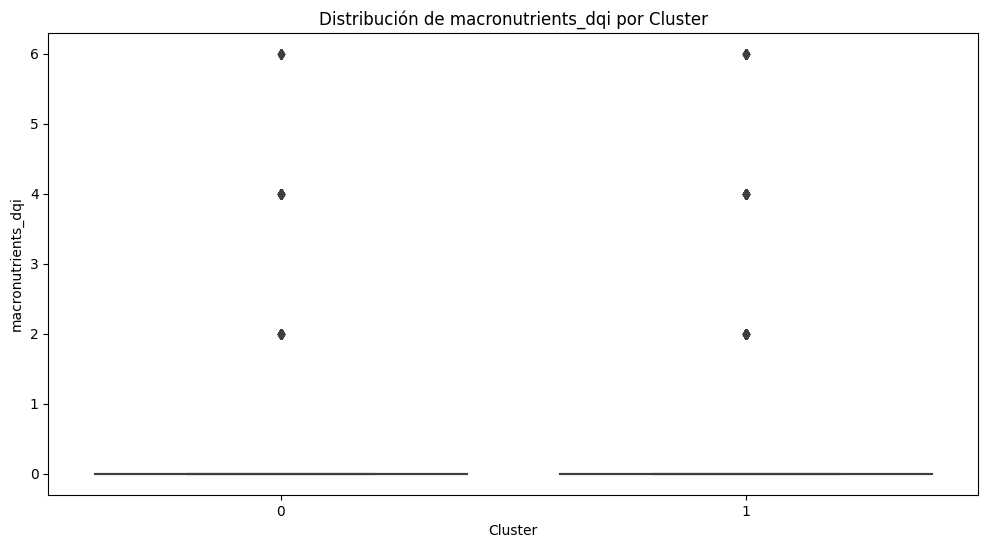

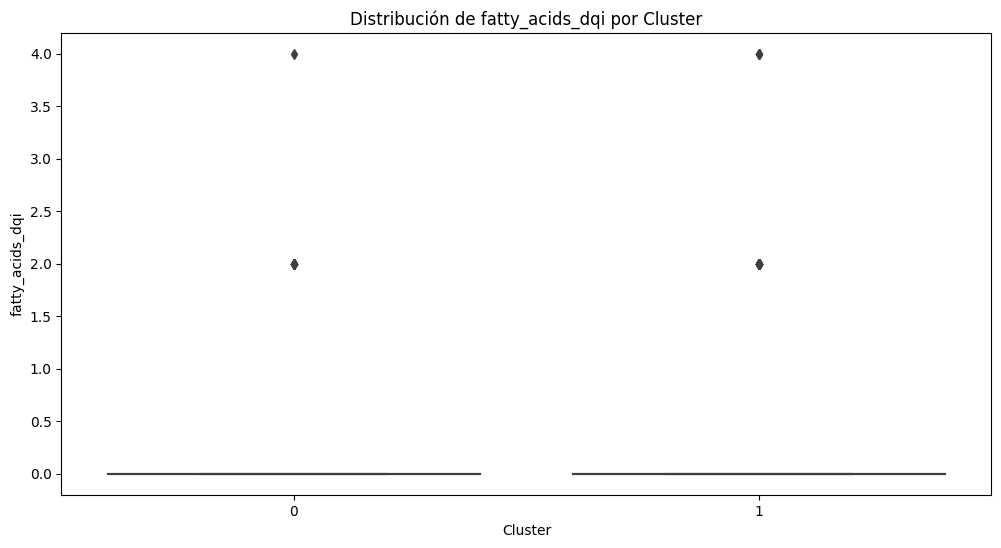

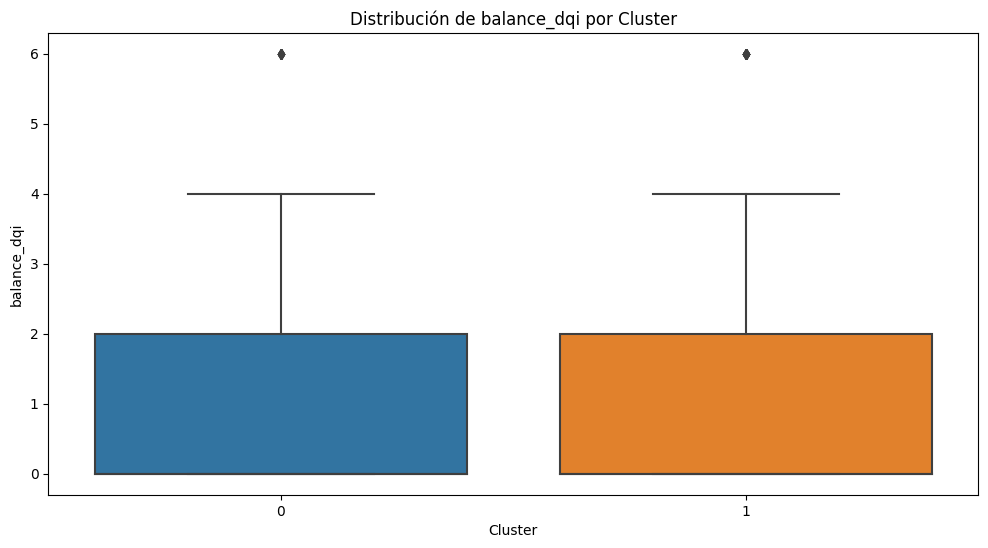

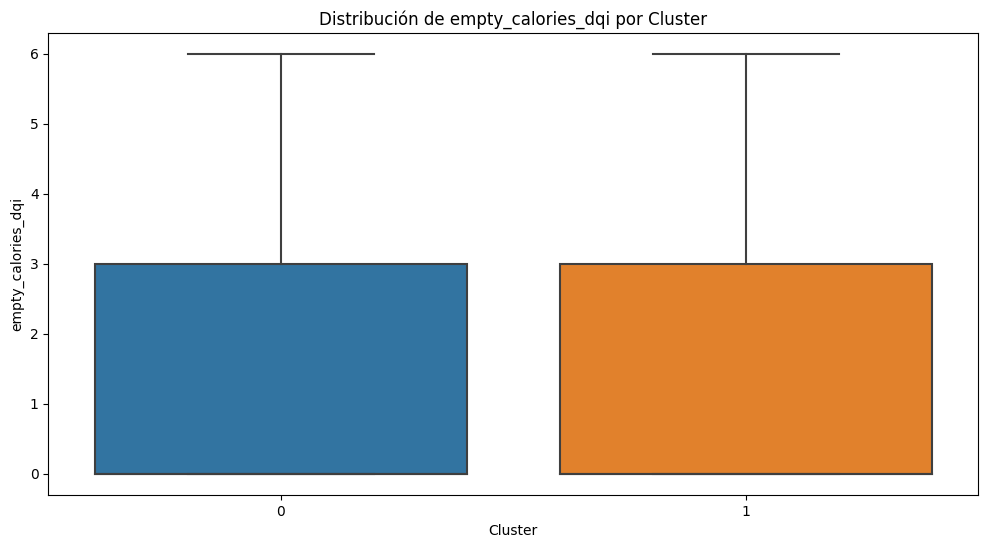

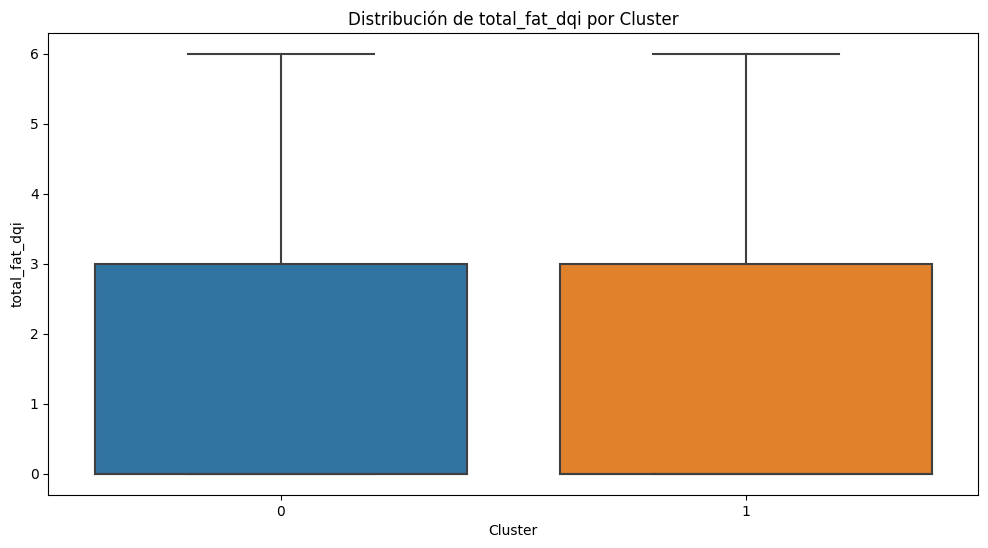

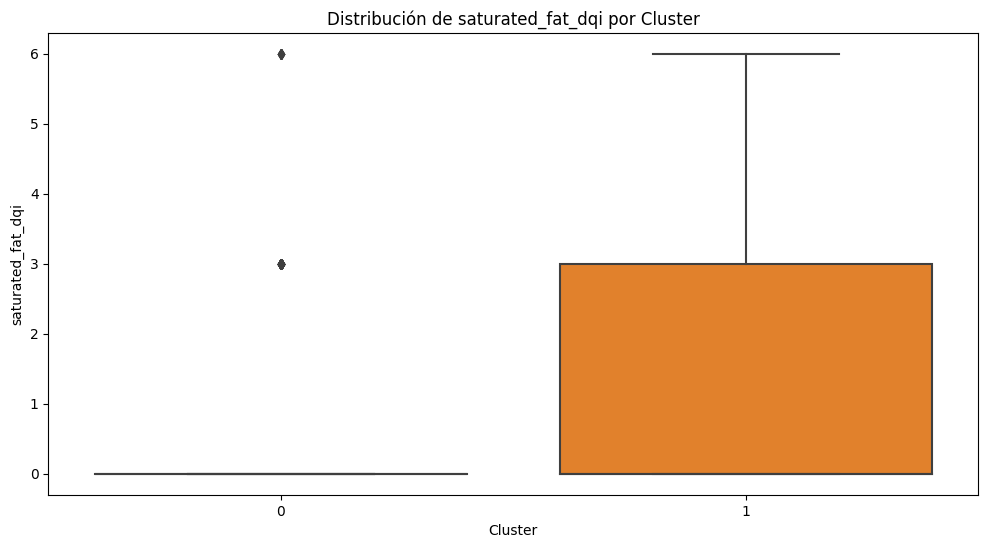

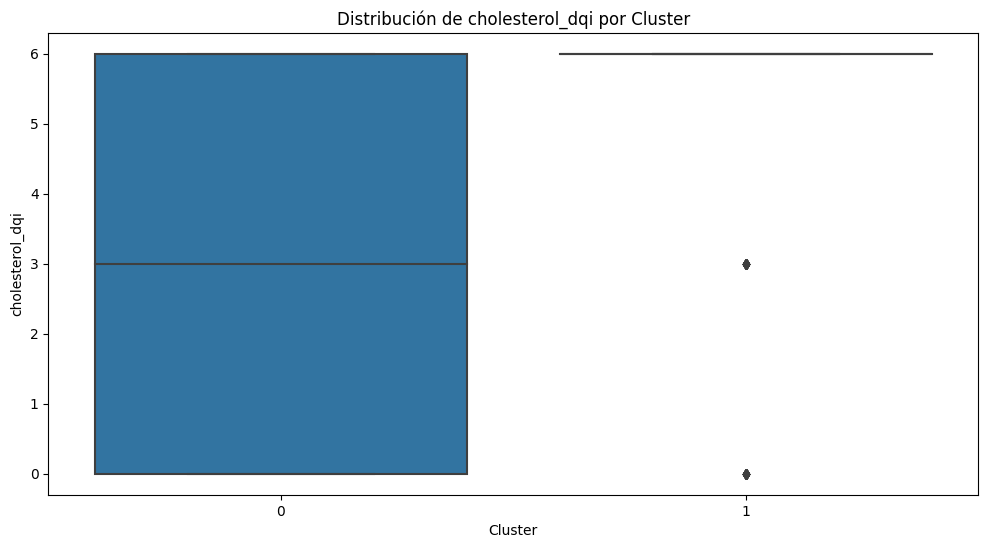

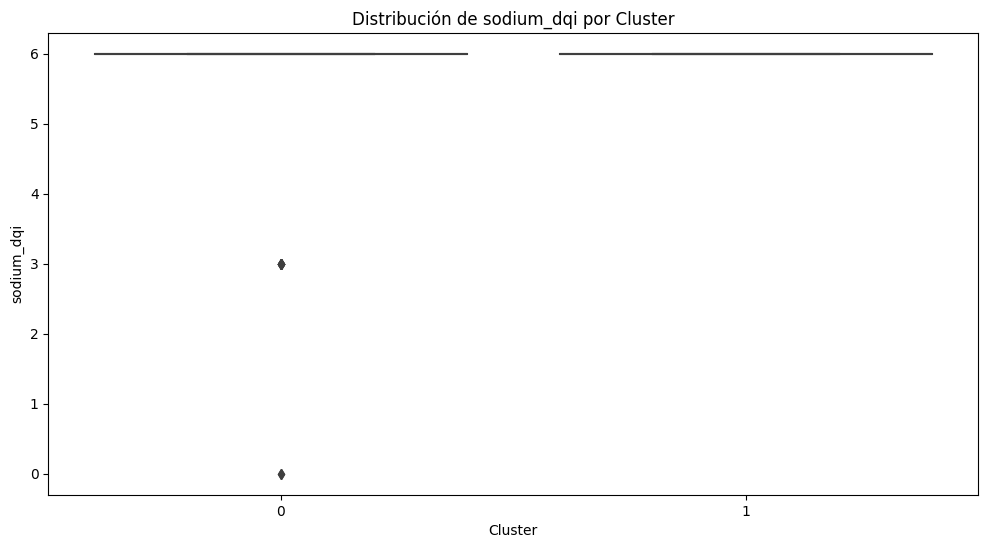

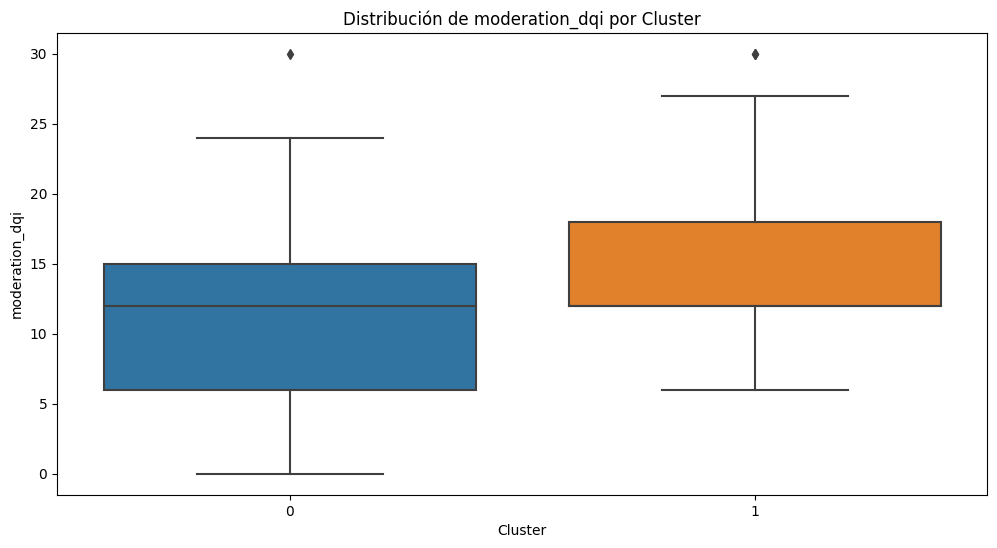

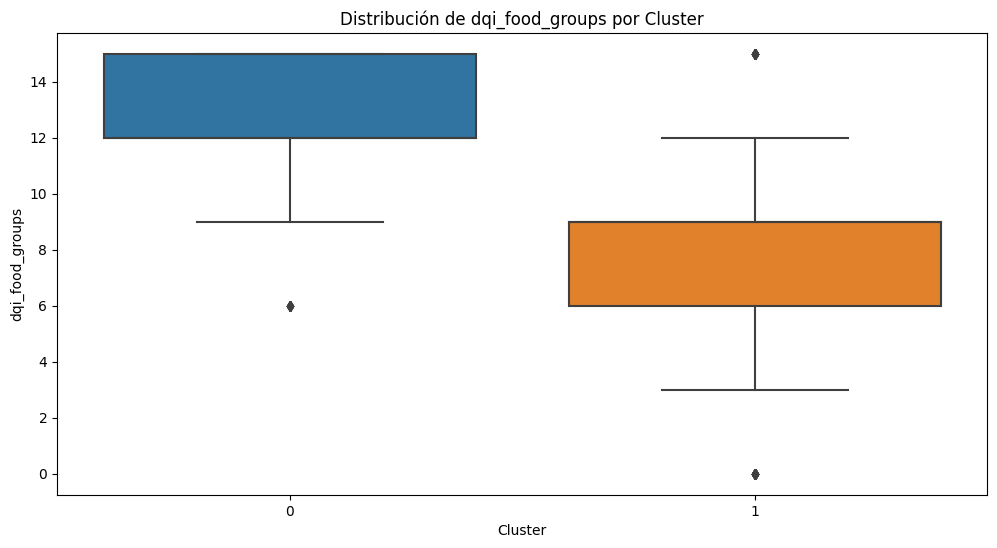

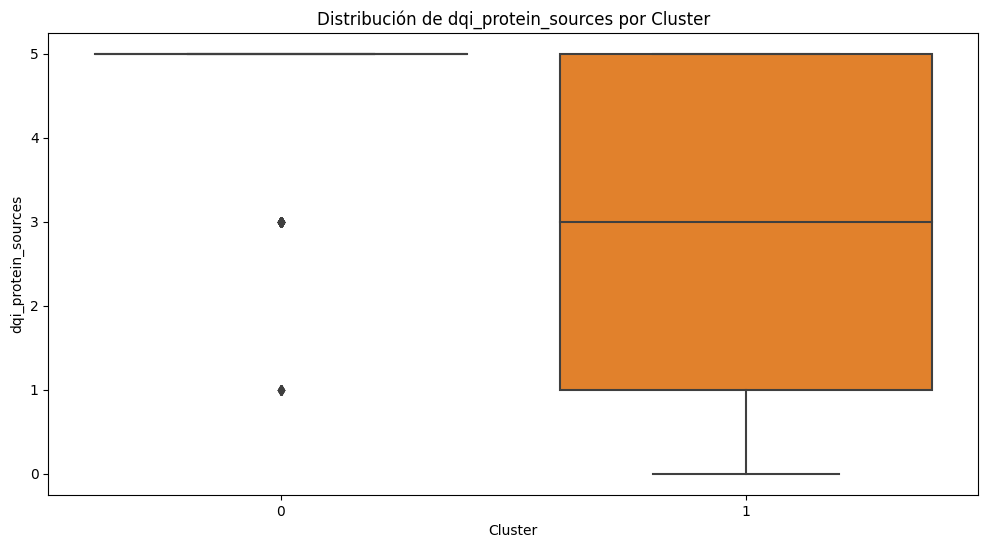

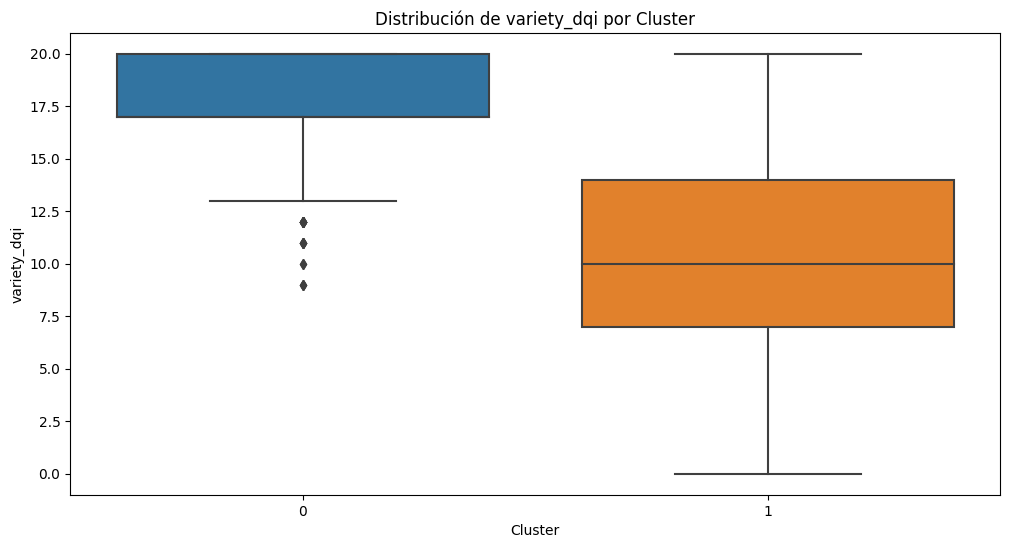

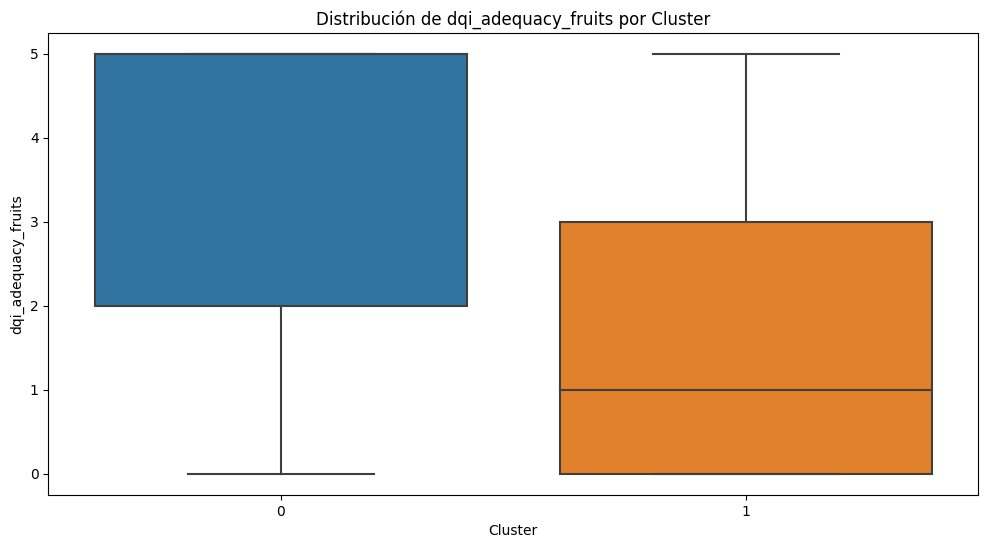

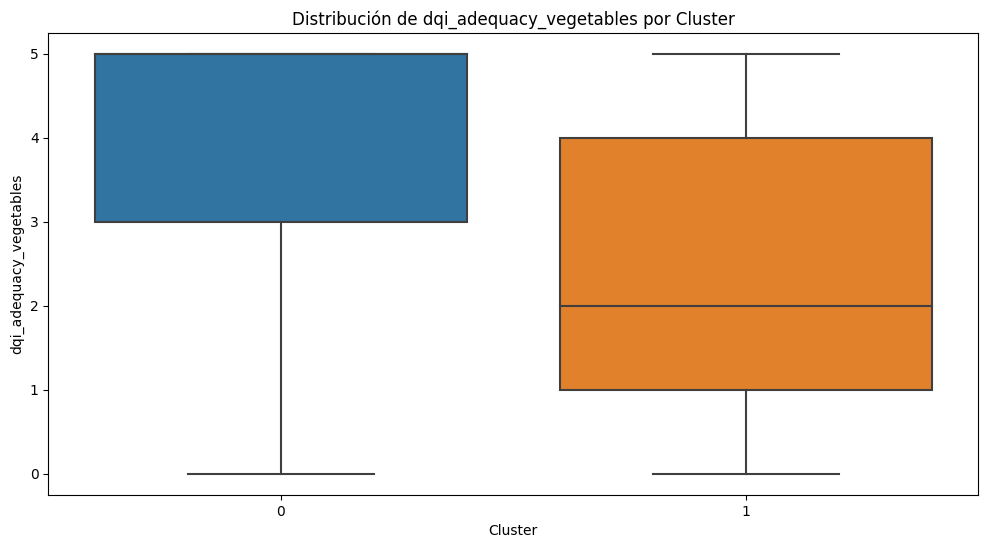

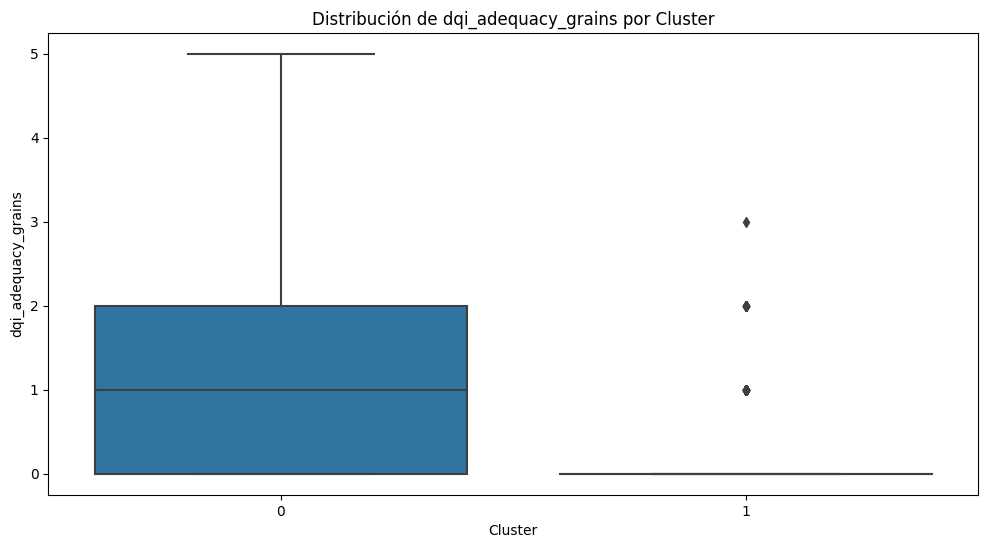

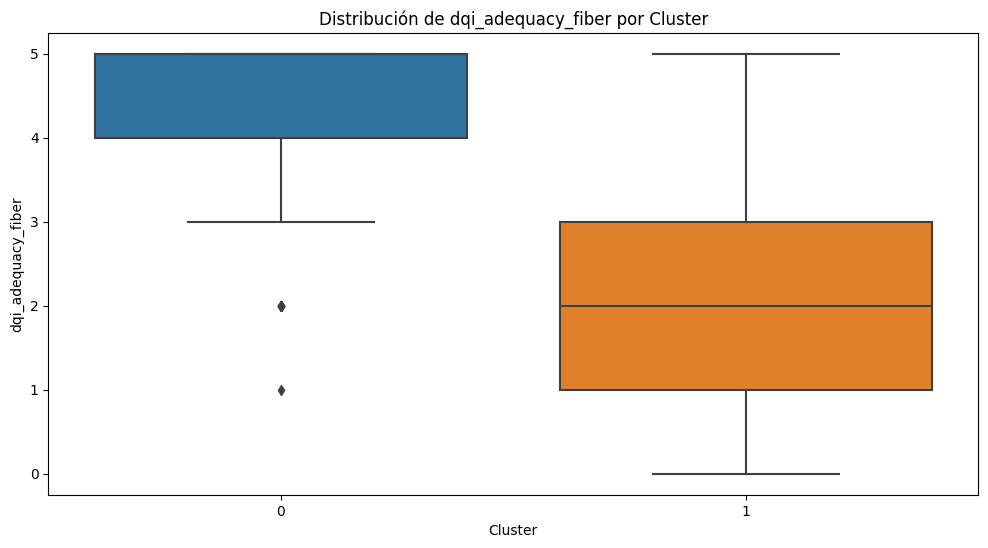

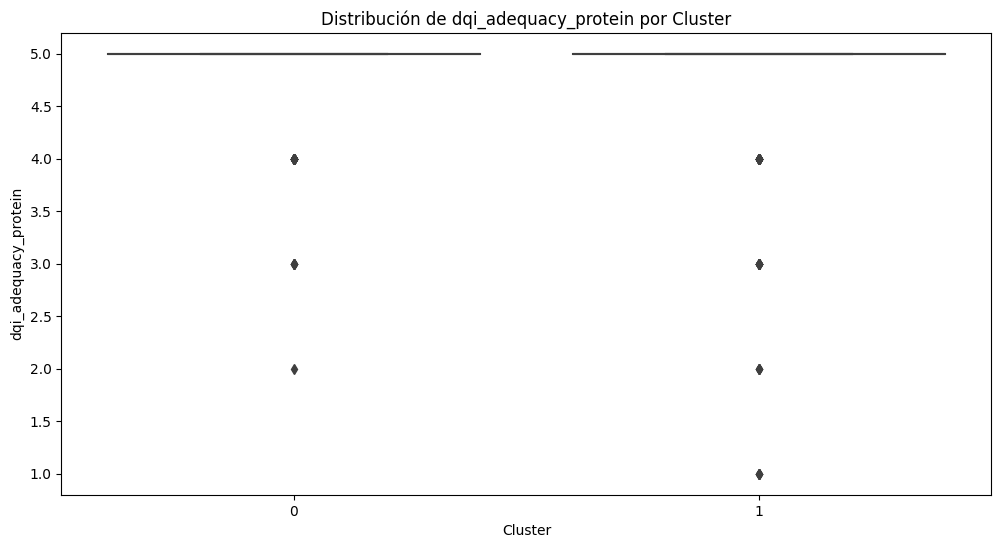

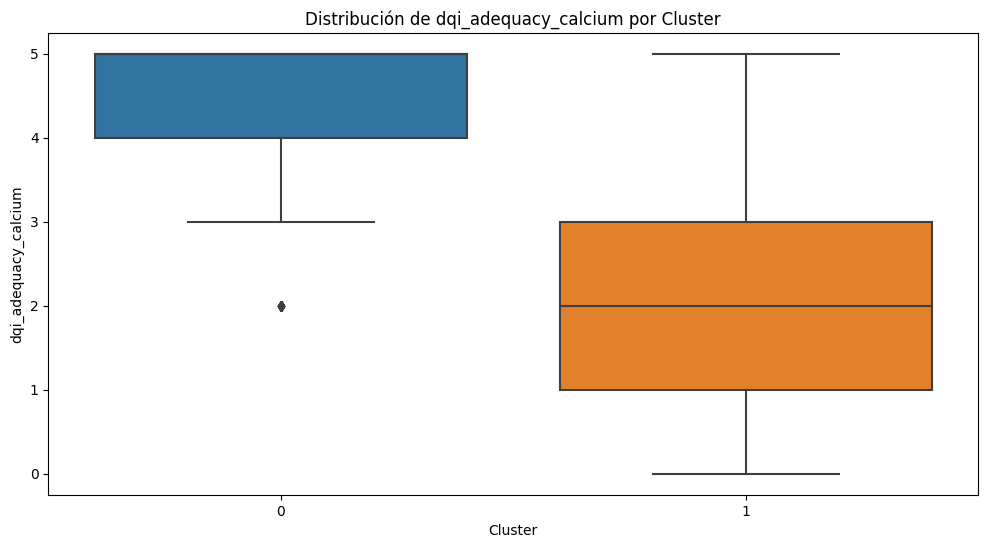

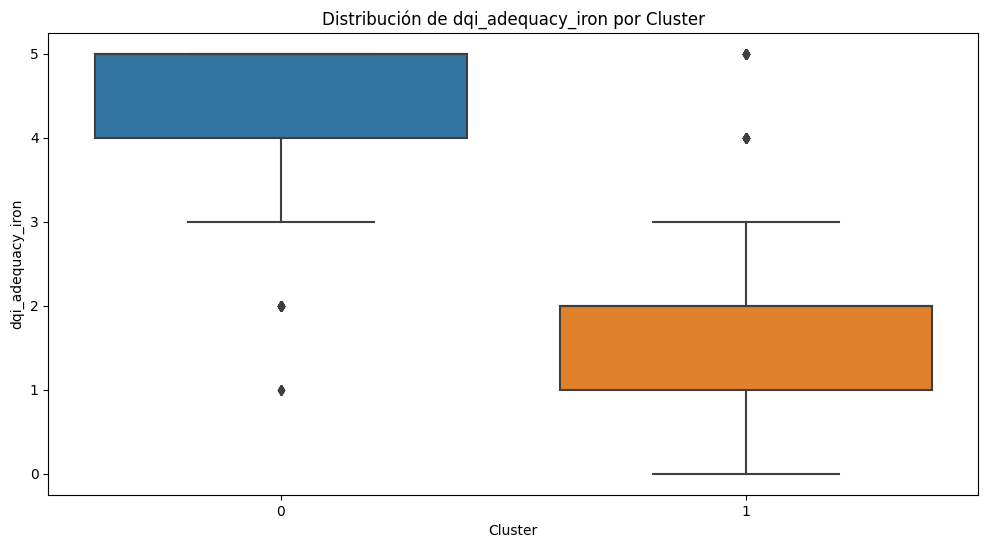

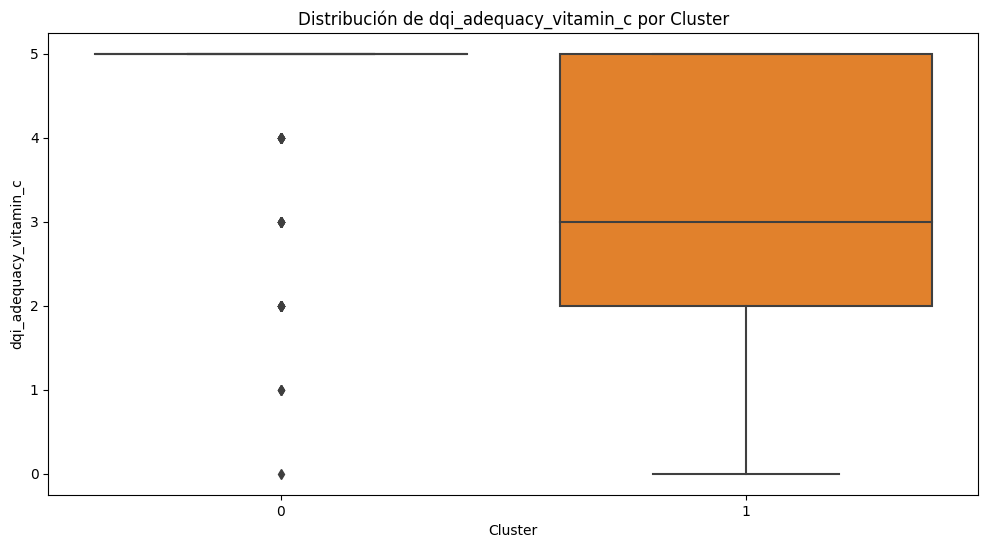

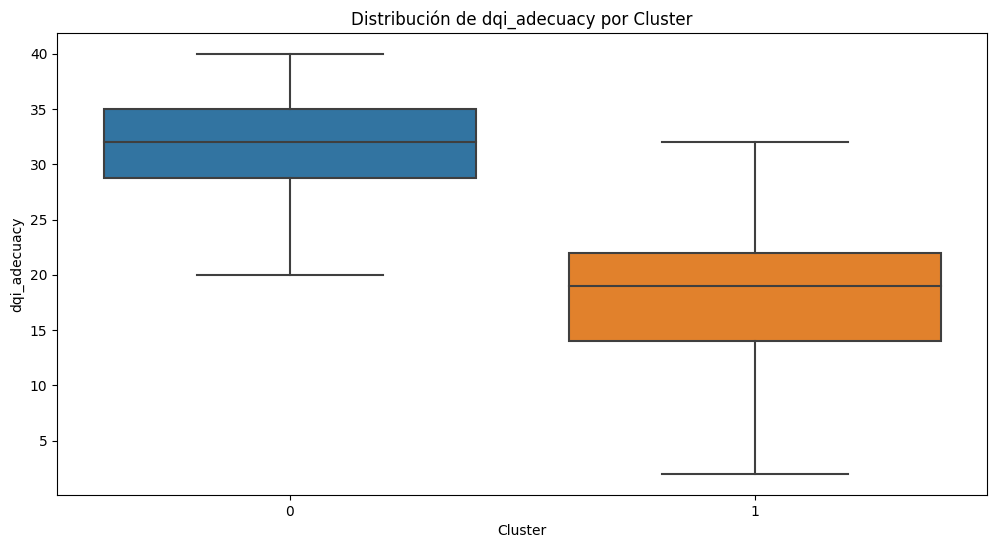

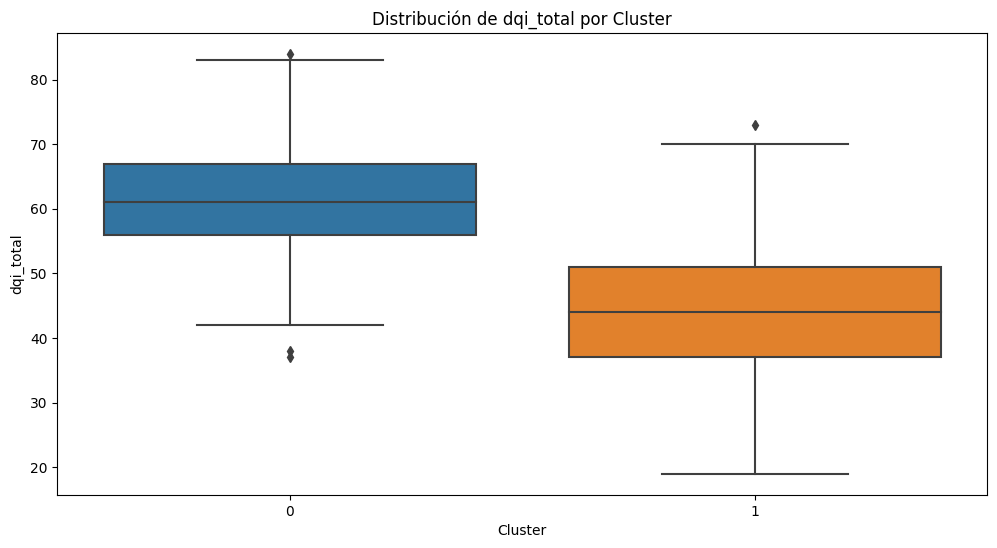

In [16]:
## Generar boxplots para todas las columnas que contengan la palabra 'dqi'
dqi_columns = df_dqi.filter(like='dqi').columns
dqi_columns.drop('dqi_total')
for column in dqi_columns:
    boxplot(df_dqi, 'Cluster', column, title=f'Distribución de {column} por Cluster')
    

Al anzalisar los boxplots de las variables DQI, se puede observar que el cluster 0 tiene valores más altos del DQI para casi todos los componentes del indicador. Por lo cual podemos concluir que en el cluster 0 tenemos segmentadas las personas con mejores dietas y en el cluster 1 personas con mayores brechas respecto a lo que se considera una dieta de alta calidad.